# Analysis & Testing for solutions

In [1]:
import pandas as pd

df = pd.read_parquet("../data/raw/data.parquet")

df_hair = df[df["category_level_2_name"] == "Hair Color"]
df_hair.head(5)

,product_id,cluster_id,country_name,title,description,category_level_1_name,category_level_2_name,category_level_3_name,brand_name,url,shade_name,image_filename
250,fd0cb918473a69efe320a494dea2d0f5fb73a1e3b9a2df...,11628001,USA,(3 pack) L'Oreal Paris Colorista Bleach Semi P...,L'Oreal Paris Colorista Bleach Semi Permanent ...,Hair,Hair Color,Bleaching,L'Oréal Paris,https://www.walmart.com/ip/L-Oreal-Paris-Color...,Ombre,fd0cb918473a69efe320a494dea2d0f5fb73a1e3b9a2df...
251,eaa181c1a5498cb893e0af43d5b1d083c5875e19301e56...,11630001,USA,L'Oreal Paris Feria Hyper Platinum Hair Color ...,L'Oreal Paris Feria Hyper Platinum Hair Color ...,Hair,Hair Color,Bleaching,L'Oréal Paris,https://www.walmart.com/ip/L-Oreal-Paris-Feria...,Hyper Platinum,eaa181c1a5498cb893e0af43d5b1d083c5875e19301e56...
252,881f35f3121372b374c9edabaa4cf7ecceaa7120626962...,40660001,USA,"Complete Kit , Lightening Bleach",Ideal for dark hair Perfect for long or thick ...,Hair,Hair Color,Bleaching,Splat,https://www.walgreens.com/store/c/splat-comple...,Lightening Bleach,881f35f3121372b374c9edabaa4cf7ecceaa7120626962...
253,6de5723f8037d757e29d7a7e823d48909ecaa86ada2d17...,40660001,USA,Splat Borderlands 3 Tyreen Blonde Lightening B...,"Sound your siren with icy blond hair, just lik...",Hair,Hair Color,Bleaching,Splat,https://www.walmart.com/ip/Splat-Borderlands-3...,Blonde,6de5723f8037d757e29d7a7e823d48909ecaa86ada2d17...
254,d53032be6d230d064c85aa4d68fd25109c0baa2f7b42b7...,40660001,USA,"Splat Lightening Bleach Kit, 4 oz.",Results depend on starting hair color and text...,Hair,Hair Color,Bleaching,Splat,https://www.amazon.com/dp/B0076OFKXK,Lightening Bleach,d53032be6d230d064c85aa4d68fd25109c0baa2f7b42b7...


In [35]:
df_colors = pd.read_parquet("../data/external/color_pedia.parquet")
df_colors.head(3)

,Color Name,HEX Code,Category,Description,Emotion,Personality,Mood,Symbolism,Use Case,Keywords,R,G,B,Hue,Saturation,Lightness,Contrast Level
0,Deep Maroon,#D62559,Red Family (Ruby Red),A vibrant and deep shade of maroon.,"Passionate, Intense","Bold, Dramatic","Strong, Powerful","Deep Maroon often symbolizes power, strength, ...",Ideal for creating a striking impact in design...,"Powerful, Passionate, Bold, Deep, Strong, Inte...",214,37,89,342.37,70.52,49.22,Dark
1,Golden Brick,#E5B262,"Warm, Earthy",A warm and inviting shade of golden brown.,"Comfort, Warmth, Optimism","Reliable, Friendly, Approachable","Cozy, Sunlit, Nurturing","Growth, Stability, Harvest",Ideal for creating a warm and inviting atmosph...,"Warm, Golden, Brown, Earthy, Comfortable, Cozy...",229,178,98,36.64,71.58,64.12,Dark
2,Lime Green,#8CCD48,"Bright, Vibrant",A lively shade of green with yellow undertones.,"Energetic, Fresh","Outgoing, Adventurous","Playful, Exciting","Growth, Renewal, Envy (in some cultures)","Ideal for modern design elements, branding for...","Bright, Vibrant, Fresh, Energy, Nature, Green,...",140,205,72,89.32,57.08,54.31,Dark


In [4]:
from sentence_transformers import SentenceTransformer, util

model = SentenceTransformer("all-mpnet-base-v2")

color_texts = (
    (df_colors["Color Name"])
    .fillna("")
    .astype(str)
    .str.lower()
    .tolist()
)

product_texts = (
    (df_hair["shade_name"])
    .fillna("")
    .astype(str)
    .str.lower()
    .tolist()
)

color_embeddings = model.encode(
    color_texts,
    convert_to_tensor=True,
    normalize_embeddings=True,
    show_progress_bar=True,
    chunk_size=4
)

product_embeddings = model.encode(
    product_texts,
    convert_to_tensor=True,
    normalize_embeddings=True,
    show_progress_bar=True,
    chunk_size=4
)

scores = util.cos_sim(product_embeddings, color_embeddings)

best_scores, best_indices = scores.max(dim=1)

df_hair["matched_color"] = [
    df_colors.iloc[i]["Color Name"] for i in best_indices.cpu().numpy()
]

df_hair["match_score"] = best_scores.cpu().numpy()

Batches:   0%|          | 0/3125 [00:00<?, ?it/s]

Batches:   0%|          | 0/193 [00:00<?, ?it/s]

C:\Users\khali\AppData\Local\Temp\ipykernel_28720\549577742.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_hair["matched_color"] = [
C:\Users\khali\AppData\Local\Temp\ipykernel_28720\549577742.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_hair["match_score"] = best_scores.cpu().numpy()


In [ ]:
df_hair[["description","shade_name", "matched_color", "match_score"]].head(15)

In [ ]:
df_hair["match_score"].mean()

In [ ]:
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches


def hex_to_rgb(hex_color):
    hex_color = str(hex_color).strip().lstrip("#")
    return tuple(int(hex_color[i:i+2], 16) for i in (0, 2, 4))


def visualize_color_matches(
    df_hair,
    df_colors,
    image_dir="../data/raw/images",
    num_samples=10,
    random_state=42
):
    sample = df_hair.sample(num_samples, random_state=random_state).reset_index(drop=True)

    _, axes = plt.subplots(
        nrows=num_samples,
        ncols=2,
        figsize=(14, num_samples * 5)
    )

    if num_samples == 1:
        axes = axes.reshape(1, 2)

    for idx, row in sample.iterrows():
        img_path = os.path.join(image_dir, row["image_filename"])

        matched_color = row["matched_color"]
        color_info = df_colors[df_colors["Color Name"] == matched_color].iloc[0]
        color_hex = color_info["HEX Code"]
        color_rgb = hex_to_rgb(color_hex)
        color_normalized = [c / 255 for c in color_rgb]

        # Product image
        # check if image is not corrupted before trying to load it
        if os.path.exists(img_path):
            axes[idx, 0].imshow(plt.imread(img_path))
            axes[idx, 0].axis("off")
            axes[idx, 0].set_title(
                f"Product: {row['shade_name']}\n"
                f"Description: {str(row['description'])[:120]}...",
                fontsize=12
            )

        # Matched color block
        axes[idx, 1].add_patch(
            patches.Rectangle(
                (0, 0),
                1,
                1,
                color=color_normalized
            )
        )
        axes[idx, 1].set_xlim(0, 1)
        axes[idx, 1].set_ylim(0, 1)
        axes[idx, 1].axis("off")
        axes[idx, 1].set_title(
            f"Matched Color: {matched_color}\n"
            f"Hex: {color_hex} | Score: {row['match_score']:.2f}",
            fontsize=12
        )

    plt.tight_layout(pad=3)
    plt.show()

visualize_color_matches(df_hair, df_colors, num_samples=20, random_state=42)

In [ ]:
import spacy
from doctr.models import ocr_predictor
from doctr.io import DocumentFile
from tqdm import tqdm

model = ocr_predictor(pretrained=True).to("cuda")

df_hair.reset_index(drop=True, inplace=True)
for idx, row in tqdm(df_hair.iterrows(), total=df_hair.shape[0]):
    try:
        doc = DocumentFile.from_images(f"../data/raw/images/{row['image_filename']}")
        results = model(doc)
        text = results.render()
        df_hair.at[idx, "ocr_text"] = text
    except Exception:
        df_hair.at[idx, "ocr_text"] = None

In [ ]:
# Save the updated DataFrame with OCR results
df_hair.to_parquet("../data/processed/data_hair_with_ocr.parquet")

In [6]:
import pandas as pd

df = pd.read_parquet("../data/processed/data_hair_with_ocr.parquet")
df.head(5)

,product_id,cluster_id,country_name,title,description,category_level_1_name,category_level_2_name,category_level_3_name,brand_name,url,shade_name,image_filename,ocr_text
0,fd0cb918473a69efe320a494dea2d0f5fb73a1e3b9a2df...,11628001,USA,(3 pack) L'Oreal Paris Colorista Bleach Semi P...,L'Oreal Paris Colorista Bleach Semi Permanent ...,Hair,Hair Color,Bleaching,L'Oréal Paris,https://www.walmart.com/ip/L-Oreal-Paris-Color...,Ombre,fd0cb918473a69efe320a494dea2d0f5fb73a1e3b9a2df...,IMPORTANT: FOLLOWTHE USAGE ADVISORY\nIMPORTANT...
1,eaa181c1a5498cb893e0af43d5b1d083c5875e19301e56...,11630001,USA,L'Oreal Paris Feria Hyper Platinum Hair Color ...,L'Oreal Paris Feria Hyper Platinum Hair Color ...,Hair,Hair Color,Bleaching,L'Oréal Paris,https://www.walmart.com/ip/L-Oreal-Paris-Feria...,Hyper Platinum,eaa181c1a5498cb893e0af43d5b1d083c5875e19301e56...,IMPORTANT: FOLLOW THE USAGE ADVISORY\nLORE\nPA...
2,881f35f3121372b374c9edabaa4cf7ecceaa7120626962...,40660001,USA,"Complete Kit , Lightening Bleach",Ideal for dark hair Perfect for long or thick ...,Hair,Hair Color,Bleaching,Splat,https://www.walgreens.com/store/c/splat-comple...,Lightening Bleach,881f35f3121372b374c9edabaa4cf7ecceaa7120626962...,- S\nColors\nRebetiaus\nLIGHTENING BLEACH\nKIT...
3,6de5723f8037d757e29d7a7e823d48909ecaa86ada2d17...,40660001,USA,Splat Borderlands 3 Tyreen Blonde Lightening B...,"Sound your siren with icy blond hair, just lik...",Hair,Hair Color,Bleaching,Splat,https://www.walmart.com/ip/Splat-Borderlands-3...,Blonde,6de5723f8037d757e29d7a7e823d48909ecaa86ada2d17...,LIGHTENING BLEACH\nTYREENBLONDE\nQUICK BLEACHI...
4,d53032be6d230d064c85aa4d68fd25109c0baa2f7b42b7...,40660001,USA,"Splat Lightening Bleach Kit, 4 oz.",Results depend on starting hair color and text...,Hair,Hair Color,Bleaching,Splat,https://www.amazon.com/dp/B0076OFKXK,Lightening Bleach,d53032be6d230d064c85aa4d68fd25109c0baa2f7b42b7...,\nd\nA\nl\nA a\n* - a . -\nA o\n/\n9\n2 a 2\na...


Text on the product:
 LIGHTENING BLEACH
TYREENBLONDE
QUICK BLEACHING ACTION
COMPLETE
KIT
BLEACHKIT AND
RECONSTRUCTOR
4
Spla
Colors
RebeNiobs
BORDERLANDSE
BORDERLANDS 3 VIP CODE INSIDE
WORTH 2000 POINTS*
LIMITED EDITION

ONE APPLICATION
18
E

*************************************

Shade name:
 Blonde

*************************************



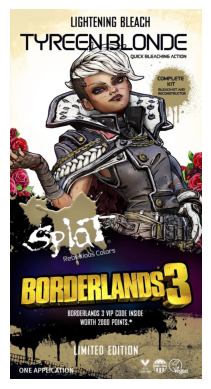

In [6]:
import matplotlib.pyplot as plt
from PIL import Image

index = 3

print("Text on the product:\n", df["ocr_text"].iloc[index])

print("\n*************************************\n")
print("Shade name:\n", df["shade_name"].iloc[index])
print("\n*************************************\n")

img = Image.open(f"../data/raw/images/{df['image_filename'].iloc[index]}")
plt.imshow(img)
plt.axis("off")  # remove axes
plt.show()

In [ ]:
from sentence_transformers import SentenceTransformer, util

model = SentenceTransformer("all-mpnet-base-v2")

color_texts = (
    (df_colors["Color Name"])
    .fillna("")
    .astype(str)
    .str.lower()
    .tolist()
)

product_texts = (
    (df["shade_name"]+" "+df["ocr_text"])
    .fillna("")
    .astype(str)
    .str.lower()
    .tolist()
)

color_embeddings = model.encode(
    color_texts,
    convert_to_tensor=True,
    normalize_embeddings=True,
    show_progress_bar=True,
    chunk_size=4
)

product_embeddings = model.encode(
    product_texts,
    convert_to_tensor=True,
    normalize_embeddings=True,
    show_progress_bar=True,
    chunk_size=4
)

scores = util.cos_sim(product_embeddings, color_embeddings)

best_scores, best_indices = scores.max(dim=1)

df["matched_color"] = [
    df_colors.iloc[i]["Color Name"] for i in best_indices.cpu().numpy()
]

df["match_score"] = best_scores.cpu().numpy()

In [ ]:
df[["ocr_text","shade_name", "matched_color", "match_score"]].head(15)

In [ ]:
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches


def hex_to_rgb(hex_color):
    hex_color = str(hex_color).strip().lstrip("#")
    return tuple(int(hex_color[i:i+2], 16) for i in (0, 2, 4))


def visualize_color_matches(
    df,
    df_colors,
    image_dir="../data/raw/images",
    num_samples=10,
    random_state=42
):
    sample = df.sample(num_samples, random_state=random_state).reset_index(drop=True)

    _, axes = plt.subplots(
        nrows=num_samples,
        ncols=2,
        figsize=(14, num_samples * 5)
    )

    if num_samples == 1:
        axes = axes.reshape(1, 2)

    for idx, row in sample.iterrows():
        img_path = os.path.join(image_dir, row["image_filename"])

        matched_color = row["matched_color"]
        color_info = df_colors[df_colors["Color Name"] == matched_color].iloc[0]
        color_hex = color_info["HEX Code"]
        color_rgb = hex_to_rgb(color_hex)
        color_normalized = [c / 255 for c in color_rgb]

        # Product image
        # check if image is not corrupted before trying to load it
        if os.path.exists(img_path):
            axes[idx, 0].imshow(plt.imread(img_path))
            axes[idx, 0].axis("off")
            axes[idx, 0].set_title(
                f"Product: {row['shade_name']}\n"
                f"Description: {str(row['description'])[:120]}...",
                fontsize=12
            )

        # Matched color block
        axes[idx, 1].add_patch(
            patches.Rectangle(
                (0, 0),
                1,
                1,
                color=color_normalized
            )
        )
        axes[idx, 1].set_xlim(0, 1)
        axes[idx, 1].set_ylim(0, 1)
        axes[idx, 1].axis("off")
        axes[idx, 1].set_title(
            f"Matched Color: {matched_color}\n"
            f"Hex: {color_hex} | Score: {row['match_score']:.2f}",
            fontsize=12
        )

    plt.tight_layout(pad=3)
    plt.show()

visualize_color_matches(df, df_colors, num_samples=20, random_state=42)

### NLP Preprocessing

In [49]:
STOPWORDS_PRODUCT = [

    # Generic marketing
    "new", "professional", "premium", "advanced",
    "exclusive", "ultimate", "perfect", "best",
    "original", "authentic", "classic", "signature",

    # Product words
    "product", "products", "formula", "technology",
    "system", "solution", "care", "treatment",
    "therapy", "routine", "collection", "line",
    "series", "kit", "pack",

    # Hair-related generic
    "hair", "capillary", "scalp", "roots",
    "strands", "fiber", "fibers",

    # Coloring generic
    "color", "colour", "coloration", "dye",
    "pigment", "pigments", "tone", "tones",
    "shade", "shades", "tint", "tints",

    # Texture / format
    "cream", "gel", "mousse", "foam",
    "spray", "paste", "wax", "powder",
    "mask", "serum", "oil", "balm",
    "conditioner", "shampoo",

    # Performance words
    "intense", "rich", "vibrant", "natural",
    "smooth", "soft", "silky", "healthy",
    "radiant", "brilliant", "luminous",
    "hydrating", "moisturizing", "repairing",
    "strengthening", "revitalizing",

    # Application words
    "apply", "application", "easy", "fast",
    "quick", "professional use", "home use",

    # Chemical / technical
    "developer", "oxidant", "peroxide",
    "activator", "booster", "stabilizer",

    # Bleaching generic
    "bleach", "bleaching", "lightener",
    "lifting", "highlift", "ultra lift",

    # Packaging
    "ml", "oz", "g", "kg", "packaging",
    "bottle", "tube", "jar",

    # French generic
    "professionnel", "formule", "produit",
    "soin", "traitement", "capillaire",
    "cheveux", "cuir chevelu",
    "creme", "crème", "gel",
    "mousse", "spray", "huile",
    "shampooing", "apres shampoing",
    "masque", "serum", "sérum",
    "intense", "riche", "naturel",
    "brillance", "hydratant",
    "reparateur", "réparateur",
    "revitalisant", "nuance",
    "teinte", "pigment",
    "oxydant", "reveleur",
    "révélateur"
]

In [50]:
import re
import unicodedata

def clean_text(text):
    text = str(text).lower()

    # remove accents
    text = unicodedata.normalize("NFKD", text)
    text = "".join(c for c in text if not unicodedata.combining(c))

    # keep only letters/numbers
    text = re.sub(r"[^a-z0-9\s]", " ", text)

    # remove stopwords
    words = [
        word for word in text.split()
        if word not in STOPWORDS_PRODUCT
    ]

    return " ".join(words)

In [51]:
COLOR_KEYWORDS = [

    # Neutral basics
    "black", "white", "gray", "grey",
    "silver", "charcoal", "graphite",

    # Browns
    "brown", "dark brown", "light brown",
    "chocolate", "mocha", "espresso",
    "chestnut", "mahogany", "hazelnut",
    "caramel", "coffee", "cocoa",

    # Blonde / yellow
    "blonde", "gold", "golden",
    "honey", "beige", "sand",
    "platinum", "vanilla",
    "butter", "champagne",

    # Red family
    "red", "crimson", "ruby",
    "burgundy", "wine", "cherry",
    "scarlet", "auburn", "copper",
    "ginger", "cinnamon", "mahogany",

    # Orange family
    "orange", "peach", "apricot",
    "coral", "tangerine", "amber",

    # Pink family
    "pink", "rose", "fuchsia",
    "magenta", "bubblegum",
    "pastel pink", "hot pink",

    # Purple family
    "purple", "violet", "lavender",
    "lilac", "plum", "eggplant",
    "amethyst",

    # Blue family
    "blue", "navy", "sky blue",
    "baby blue", "cyan", "turquoise",
    "teal", "aqua", "electric blue",
    "midnight blue", "ocean",

    # Green family
    "green", "mint", "lime",
    "olive", "emerald", "jade",
    "forest", "sage", "khaki",
    "neon green",

    # Metallic / fantasy
    "metallic", "chrome", "steel",
    "icy", "smoky", "smoke",
    "pearl", "opal", "iridescent",

    # Fashion/fantasy shades
    "pastel", "neon", "rainbow",
    "unicorn", "galaxy", "mermaid",

    # Tone modifiers
    "ash", "ashy", "warm", "cool",
    "neutral", "deep", "light",
    "dark", "intense", "soft",

    # French
    "noir", "blanc", "gris",
    "argent", "brun", "chatain",
    "blond", "dore", "cuivre",
    "rouge", "rose", "violet",
    "bleu", "vert", "jaune",
    "orange", "turquoise",
    "menthe", "olive",
    "platine", "acajou",
    "bordeaux", "miel",
    "caramel", "cendre"
]

In [52]:
def extract_color_keywords(text):
    text = clean_text(text)
    found = []
    
    for keyword in COLOR_KEYWORDS:
        if re.search(rf"\b{re.escape(keyword)}\b", text):
            found.append(keyword)
    
    return found

In [53]:
def extract_color_phrases(text):
    text = clean_text(text)
    
    patterns = [
        r"\b(?:light|dark|medium|deep|golden|ash|bronzed)\s+\w+",
        r"\b(?:brun|chatain|blond|noir|roux)\s+\w+",
        r"\b\w+\s+(?:brown|blonde|black|red|copper|bronze)"
    ]
    
    phrases = []
    for pattern in patterns:
        phrases.extend(re.findall(pattern, text))
    
    return list(set(phrases))

In [54]:
VOLUME_COLOR_HINTS = {
    10: ["dark", "brown", "natural"],
    20: ["brown", "auburn", "chestnut"],
    30: ["blonde", "golden", "copper"],
    40: ["platinum", "bleach", "silver", "icy"]
}

def extract_volume_hints(text):
    text = str(text).lower()

    matches = re.findall(
        r"\b(\d+)\s*(?:vol(?:ume)?s?\.?)\b",
        text,
        flags=re.IGNORECASE
    )

    hints = []

    for match in matches:
        volume = int(match)
        hints.extend(VOLUME_COLOR_HINTS.get(volume, []))

    return hints

# 1st Solution

In [ ]:
def weighted_terms(text, weight=1):
    terms = extract_color_keywords(text) + extract_color_phrases(text)
    return terms * weight

In [72]:
df["color_vector"] = df["ocr_text"].apply(
                        lambda x: (
                            weighted_terms(x, weight=2)
                        )
                    )+df["description"].apply(
                        lambda x: (
                            weighted_terms(x, weight=1)
                        )
                    )+df["category_level_3_name"].apply(
                        lambda x: (
                            ["blonde"]*3 if x == "Bleaching" else []
                        )
                    )+df["shade_name"].apply(
                            lambda x: [str(x).lower()] + extract_volume_hints(x.lower())
                    )

In [97]:
df[["color_vector"]].head(10)

,color_vector
0,"[blonde, blonde, blonde, ombre]"
1,"[platinum, purple, platinum, purple, brown, da..."
2,"[dark, dark for, blonde, blonde, blonde, light..."
3,"[icy, deep, blond, blond just, deep reconstruc..."
4,"[blonde, blonde, blonde, lightening bleach]"
5,"[silver, silver, silver, green, mint, cool, de..."
6,"[blonde, sarnier blonde, lasting blonde, blond..."
7,"[blonde, blonde, blonde, white]"
8,"[warm, cool, blonde, blonde, blonde, 20 volume..."
9,"[light, light brom, light, light brom, grey, o..."


In [74]:
from sentence_transformers import SentenceTransformer, util

model = SentenceTransformer("all-mpnet-base-v2")

color_texts = (
    (df_colors["Color Name"])
    .fillna("")
    .astype(str)
    .str.lower()
    .tolist()
)

product_texts = (
    df["color_vector"]
    .apply(lambda x: " ".join(x) if isinstance(x, list) else str(x))
    .fillna("")
    .tolist()
)

product_embeddings = model.encode(
    product_texts,
    convert_to_tensor=True,
    normalize_embeddings=True,
    show_progress_bar=True,
    chunk_size=4
)

color_embeddings = model.encode(
    color_texts,
    convert_to_tensor=True,
    normalize_embeddings=True,
    show_progress_bar=True,
    chunk_size=4
)



scores = util.cos_sim(product_embeddings, color_embeddings)

best_scores, best_indices = scores.max(dim=1)

df["matched_color"] = [
    df_colors.iloc[i]["Color Name"] for i in best_indices.cpu().numpy()
]

df["match_score"] = best_scores.cpu().numpy()

Batches:   0%|          | 0/193 [00:00<?, ?it/s]

Batches:   0%|          | 0/3125 [00:00<?, ?it/s]

In [75]:
df[["color_vector", "matched_color", "match_score"]].head(20)

,color_vector,matched_color,match_score
0,"[blonde, blonde, blonde, ombre]",Orange-Brown (Orangey-Brown),0.582508
1,"[platinum, purple, platinum, purple, brown, da...","Purple-Red (Dull Violet, Magenta-Violet)",0.709215
2,"[dark, dark for, blonde, blonde, blonde, light...",Light Cyanish Violet,0.593840
3,"[icy, deep, blond, blond just, deep reconstruc...",Deep Cyanic Purple,0.509308
4,"[blonde, blonde, blonde, lightening bleach]",Cyanish Violet,0.612642
5,"[silver, silver, silver, green, mint, cool, de...",Silver-Blue-Grey,0.671988
6,"[blonde, sarnier blonde, lasting blonde, blond...",Green-yellow (Bright Yellow-Green),0.594472
7,"[blonde, blonde, blonde, white]",Gold Yellow,0.576885
8,"[warm, cool, blonde, blonde, blonde, 20 volume...",Lavender Pinkish Yellow,0.710357
9,"[light, light brom, light, light brom, grey, o...",Orange-Brown (Orange-Burnt Sienna),0.643650


In [ ]:
print("la moyenne est", df["match_score"].mean())
print("le minimum est", df["match_score"].min())
print("le maximum est", df["match_score"].max())

la moyenne est 0.6511312
le minimum est 0.24230889976024628
le maximum est 1.0000008344650269


In [96]:
df[df["match_score"] > 0.8][["match_score","shade_name","matched_color"]].head(20)

,match_score,shade_name,matched_color
109,0.814748,White,Light Pastel Grey
110,0.890462,Aqua,Ocean Aqua
133,0.824705,T12 Silver Mist,Silver Mist
139,0.935306,Brown,Grayish Brown
141,0.811646,Natural Black,Dark Blue Gray
149,0.891398,Light Brown,Light Grayish Brown
150,0.859592,Medium Brown,Medium Grayish Brown
153,0.834401,Silver Lilac,Silver-Lilac
160,0.857162,Brown,Silver Grayish Blue
166,0.932102,Light Brown,Dark Brown


In [1]:
import torch
import transformers

print(torch.__version__)
print(transformers.__version__)

c:\Users\khali\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.
0it [00:00, ?it/s]

2.5.1+cu118
4.46.3


In [ ]:
from pathlib import Path
import pandas as pd
from tqdm import tqdm
import ollama

# =========================
# CONFIG
# =========================

PARQUET_PATH = "../data/raw/data.parquet"
IMAGE_FOLDER = "../data/raw/images"
OUTPUT_CSV = "../data/processed/hair_color_llava_annotations.csv"

CATEGORY_COL = "category_level_2_name"
IMAGE_COL = "image_filename"       # change to your real image filename column
PRODUCT_NAME_COL = "title"  # change if needed

MODEL_NAME = "llava"

# =========================
# VLM ANNOTATION FUNCTION
# =========================

def ask_vlm_for_color(image_path, product_name=None):
    prompt = f"""
You are annotating a hair color product image.

Look at the image and identify the visible hair color / shade of the product.

You can strongly rely on the text on the product to identify the shade, but also look for visual cues in the image.

If there is more than one product in the image, return a list of shades separated by comma.

Product name: {product_name}

Return ONLY a short color/shade label.
Examples:
- dark brown
- light brown
- ash blonde
- golden blonde
- copper brown
- burgundy
- black
- platinum blonde
- etc.

Do not describe the packaging.
Do not write a sentence.
Only return the shade label.
"""

    response = ollama.chat(
        model=MODEL_NAME,
        messages=[
            {
                "role": "user",
                "content": prompt,
                "images": [str(image_path)]
            }
        ]
    )

    return response["message"]["content"].strip().lower()


# =========================
# MAIN PIPELINE
# =========================

def annotate_hair_color_products(number_of_products=None):
    metadata = pd.read_parquet(PARQUET_PATH)

    hair_color_df = metadata[
        metadata[CATEGORY_COL]
        .fillna("")
        .astype(str)
        .str.lower()
        .str.strip()
        .eq("hair color")
    ].copy()

    if number_of_products is not None:
        hair_color_df = hair_color_df.head(number_of_products)

    print("Total products:", len(metadata))
    print("Hair color products:", len(hair_color_df))

    rows = []

    for _, row in tqdm(hair_color_df.iterrows(), total=len(hair_color_df)):
        filename = row[IMAGE_COL]
        image_path = Path(IMAGE_FOLDER) / str(filename)

        base_row = row.to_dict()

        if not image_path.exists():
            rows.append({
                **base_row,
                "image_path": str(image_path),
                "vlm_predicted_shade": None,
                "error": "image not found"
            })
            continue

        try:
            product_name = row.get(PRODUCT_NAME_COL, "")

            shade = ask_vlm_for_color(
                image_path=image_path,
                product_name=product_name
            )

            rows.append({
                **base_row,
                "image_path": str(image_path),
                "vlm_predicted_shade": shade,
                "error": None
            })

        except Exception as e:
            rows.append({
                **base_row,
                "image_path": str(image_path),
                "vlm_predicted_shade": None,
                "error": str(e)
            })

    result_df = pd.DataFrame(rows)

    Path(OUTPUT_CSV).parent.mkdir(parents=True, exist_ok=True)
    result_df.to_csv(OUTPUT_CSV, index=False)

    return result_df


df = annotate_hair_color_products()
df.head()

Total products: 74125
Hair color products: 5


100%|██████████| 5/5 [00:03<00:00,  1.29it/s]


,product_id,cluster_id,country_name,title,description,category_level_1_name,category_level_2_name,category_level_3_name,brand_name,url,shade_name,image_filename,image_path,vlm_predicted_shade,error
0,fd0cb918473a69efe320a494dea2d0f5fb73a1e3b9a2df...,11628001,USA,(3 pack) L'Oreal Paris Colorista Bleach Semi P...,L'Oreal Paris Colorista Bleach Semi Permanent ...,Hair,Hair Color,Bleaching,L'Oréal Paris,https://www.walmart.com/ip/L-Oreal-Paris-Color...,Ombre,fd0cb918473a69efe320a494dea2d0f5fb73a1e3b9a2df...,..\data\raw\images\fd0cb918473a69efe320a494dea...,"purple, gray, blue",None
1,eaa181c1a5498cb893e0af43d5b1d083c5875e19301e56...,11630001,USA,L'Oreal Paris Feria Hyper Platinum Hair Color ...,L'Oreal Paris Feria Hyper Platinum Hair Color ...,Hair,Hair Color,Bleaching,L'Oréal Paris,https://www.walmart.com/ip/L-Oreal-Paris-Feria...,Hyper Platinum,eaa181c1a5498cb893e0af43d5b1d083c5875e19301e56...,..\data\raw\images\eaa181c1a5498cb893e0af43d5b...,platinum blonde,None
2,881f35f3121372b374c9edabaa4cf7ecceaa7120626962...,40660001,USA,"Complete Kit , Lightening Bleach",Ideal for dark hair Perfect for long or thick ...,Hair,Hair Color,Bleaching,Splat,https://www.walgreens.com/store/c/splat-comple...,Lightening Bleach,881f35f3121372b374c9edabaa4cf7ecceaa7120626962...,..\data\raw\images\881f35f3121372b374c9edabaa4...,lightening bleach,None
3,6de5723f8037d757e29d7a7e823d48909ecaa86ada2d17...,40660001,USA,Splat Borderlands 3 Tyreen Blonde Lightening B...,"Sound your siren with icy blond hair, just lik...",Hair,Hair Color,Bleaching,Splat,https://www.walmart.com/ip/Splat-Borderlands-3...,Blonde,6de5723f8037d757e29d7a7e823d48909ecaa86ada2d17...,..\data\raw\images\6de5723f8037d757e29d7a7e823...,tyreen blonde,None
4,d53032be6d230d064c85aa4d68fd25109c0baa2f7b42b7...,40660001,USA,"Splat Lightening Bleach Kit, 4 oz.",Results depend on starting hair color and text...,Hair,Hair Color,Bleaching,Splat,https://www.amazon.com/dp/B0076OFKXK,Lightening Bleach,d53032be6d230d064c85aa4d68fd25109c0baa2f7b42b7...,..\data\raw\images\d53032be6d230d064c85aa4d68f...,platinum blonde,None


In [10]:
print('Error:', df["error"][1])

Error: {"error":{"code":400,"message":"Multimodal data provided, but model does not support multimodal requests.","type":"invalid_request_error"}} (status code: 400)
